# Momentum

Momentum is the empirical tendency for recent winners to continue outperforming recent losers over intermediate horizons. This notebook builds the idea from stock-level portfolio sorts to momentum across factor returns. The objective is educational: the analysis uses transparent implementations and standard asset-pricing tests, but it is not an exact replication of any single paper.

The organizing question is whether information in returns observed before month $t$ helps explain returns earned in month $t$.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from factor_asset_pricing.asset_pricing_tests import (
    factor_regressions,
    grs_test,
    performance_summary,
    sharpe_ratio,
    pricing_error_summary,
    time_series_regression,
)
from factor_asset_pricing.characteristics import adjusted_return, market_equity
from factor_asset_pricing.momentum import (
    conditional_future_returns,
    factor_momentum,
    lagged_correlation_matrix,
    momentum_signal,
    stock_momentum,
)
from factor_asset_pricing.sorts import lag_characteristics, sort_portfolios

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.3f}".format

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FF5_PROJECT = ROOT.parent / "01_complete" / "fama-french-five-factor-replication"
VM_PROJECT = ROOT.parent / "01_complete" / "volatility-management-and-liquidity"
PANEL_PATH = Path(os.environ.get("FAP_CRSP_COMPUSTAT_PANEL", FF5_PROJECT / "data/interim/Python/crsp_compustat_monthly_panel_1950_2024.parquet"))
FACTOR_PATH = Path(os.environ.get("FAP_FF5_FACTOR_DATA", FF5_PROJECT / "data/interim/Python/ff5_factors_internal.parquet"))
OFFICIAL_PATH = Path(os.environ.get("FAP_VOLATILITY_DATA", VM_PROJECT / "data/processed/managed_factors.parquet"))

for path in [PANEL_PATH, FACTOR_PATH, OFFICIAL_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Required prepared data not found: {path}")

factor_data = pd.read_parquet(FACTOR_PATH)
factor_data["mdate"] = pd.to_datetime(factor_data["mdate"]).dt.to_period("M").dt.to_timestamp()
factor_data = factor_data.set_index("mdate")
factors = factor_data[["MKT", "SMB", "HML", "RMW", "CMA"]].dropna()
risk_free = factor_data["RF"].rename("RF")

official = pd.read_parquet(OFFICIAL_PATH)
official["date"] = pd.to_datetime(official["date"]).dt.to_period("M").dt.to_timestamp()
official = official.set_index("date")
umd = official["mom"].rename("UMD")

print(f"FF5 sample: {factors.index.min():%B %Y}–{factors.index.max():%B %Y} ({len(factors)} months)")

FF5 sample: July 1962–December 2024 (750 months)


## 1. The momentum effect

A simple predictability benchmark holds expected returns constant across the information in past prices and returns. For the information set $\mathcal I_{t-1}$ available before month $t$, this restriction is:

$$E[R_t\mid\mathcal I_{t-1}]=E[R_t].$$

Market efficiency does not itself impose this constant-mean restriction: equilibrium risk premia can vary predictably. Testing abnormal profits jointly tests efficiency and the expected-return model (Fama, 1970). Momentum describes a departure from the simpler benchmark at intermediate horizons. It does not imply positive dependence at every horizon. Short-run reversals, intermediate-horizon continuation, and long-run reversals can coexist:

$$\text{short-run reversal}\;\longrightarrow\;\text{intermediate momentum}\;\longrightarrow\;\text{long-run reversal}.$$

**Time-series momentum** asks whether an asset continues in the direction of its own past return. **Cross-sectional momentum** asks whether relative winners continue to outperform relative losers. Jegadeesh and Titman (1993) established the intermediate-horizon winner–loser pattern in US stocks. Hong and Stein (1999) model gradual information diffusion and momentum trading as a mechanism for underreaction and subsequent overreaction; risk-based accounts emphasize time-varying exposures and adverse-state payoffs. Daniel and Moskowitz (2016) document severe momentum crashes, but crash risk by itself does not identify the source of the unconditional premium. Predictability is therefore evidence against the simplest constant-expected-return benchmark, not by itself proof of market inefficiency.

## 2. The momentum factor: Cross-sectional stock momentum

Cross-sectional momentum compares securities with one another: recent relative winners are held long and recent relative losers are held short. Before constructing the canonical factor, it is useful to establish why predictability in a diversified portfolio need not come only from each stock repeating its own return. Return dependence can also operate across securities when some groups incorporate information before others.

In [2]:
stocks = pd.read_parquet(
    PANEL_PATH,
    columns=["permno", "mdate", "ret", "dlret", "prc", "shrout", "exchcd"],
)
stocks["ret_adj"] = adjusted_return(stocks["ret"], stocks["dlret"])
stocks["market_equity"] = market_equity(stocks["prc"], stocks["shrout"])
stocks = stocks.rename(columns={"permno": "id", "mdate": "date", "exchcd": "exchange"})
stocks["date"] = pd.to_datetime(stocks["date"]).dt.to_period("M").dt.to_timestamp()
stocks = stocks.loc[
    stocks["exchange"].isin([1, 2, 3])
    & stocks["ret_adj"].notna()
    & stocks["market_equity"].gt(0)
].copy()

### 2.1 Empirical foundation: own effects and size-based lead–lag relations

A profitable return-based strategy does not require every stock to have strong own-return autocorrelation. Campbell, Lo, and MacKinlay (1997) use the Lo and MacKinlay (1990) evidence to show that portfolio predictability can also arise because one security or portfolio leads another. For an $N$-asset return vector $\mathbf R_t$, define the lag-one covariance matrix

$$\boldsymbol\Gamma(1)=\operatorname{Cov}(\mathbf R_t,\mathbf R_{t-1}).$$

For the equally weighted portfolio $R_{p,t}=N^{-1}\mathbf 1'\mathbf R_t$, its lag-one autocovariance separates into own effects and cross-effects:

$$\operatorname{Cov}(R_{p,t},R_{p,t-1})=\frac{1}{N^2}\sum_i\operatorname{Cov}(R_{i,t},R_{i,t-1})+\frac{1}{N^2}\sum_{i\neq j}\operatorname{Cov}(R_{i,t},R_{j,t-1}).$$

The first term is the **own effect**: whether each portfolio's own return tends to be followed by a return in the same direction. The second is the **cross-effect**: whether the past return on one portfolio predicts the current return on another. A positive cross-effect does not mean that small firms are especially correlated with their own histories. The original result is instead asymmetric—large-stock returns tend to lead later small-stock returns more strongly than small stocks lead large stocks. Rows in the matrix below are current returns and columns are returns lagged by one month.

The covariance decomposition assumes finite second moments and a stable lag-covariance interpretation over the sample. Estimated lead–lag covariances are descriptive associations, not causal evidence or significance tests by themselves.


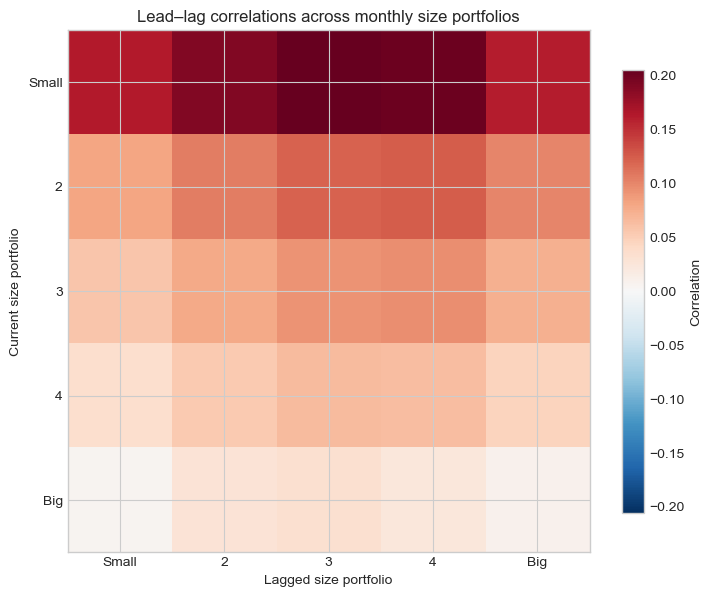

,Estimate
Own-effect autocovariance (%²),0.567
Cross-effect autocovariance (%²),2.097
Total portfolio autocovariance (%²),2.664
Portfolio autocorrelation,0.103
Big leads small correlation,0.162
Small leads big correlation,0.005


In [3]:
size_panel = lag_characteristics(stocks, "market_equity", lags=1)
size_portfolios, _ = sort_portfolios(
    size_panel,
    "market_equity_lag1",
    n_portfolios=5,
    return_col="ret_adj",
    reference="nyse",
    weighting="vw",
    weight_col="market_equity",
)
size_returns = size_portfolios.pivot(index="date", columns="market_equity_lag1_portfolio", values="ret").dropna()
size_returns.columns = ["Small", "2", "3", "4", "Big"]
lead_lag = lagged_correlation_matrix(size_returns, lag=1)

aligned = pd.concat({"current": size_returns, "lagged": size_returns.shift(1)}, axis=1).dropna()
current = aligned["current"] - aligned["current"].mean()
lagged = aligned["lagged"] - aligned["lagged"].mean()
gamma_1 = current.T.dot(lagged) / (len(aligned) - 1)
n_assets = gamma_1.shape[0]
own_component = np.trace(gamma_1) / n_assets**2
cross_component = (gamma_1.to_numpy().sum() - np.trace(gamma_1)) / n_assets**2
index_return = size_returns.mean(axis=1)
decomposition = pd.Series({
    "Own-effect autocovariance (%²)": 10_000 * own_component,
    "Cross-effect autocovariance (%²)": 10_000 * cross_component,
    "Total portfolio autocovariance (%²)": 10_000 * (own_component + cross_component),
    "Portfolio autocorrelation": index_return.autocorr(1),
    "Big leads small correlation": lead_lag.loc["Small", "Big"],
    "Small leads big correlation": lead_lag.loc["Big", "Small"],
})

fig, ax = plt.subplots(figsize=(7.4, 6.2))
limit = np.nanmax(np.abs(lead_lag.to_numpy()))
image = ax.imshow(lead_lag, cmap="RdBu_r", vmin=-limit, vmax=limit)
ax.set(title="Lead–lag correlations across monthly size portfolios", xlabel="Lagged size portfolio", ylabel="Current size portfolio", xticks=range(5), xticklabels=lead_lag.columns, yticks=range(5), yticklabels=lead_lag.index)
fig.colorbar(image, ax=ax, label="Correlation", shrink=0.8)
plt.tight_layout()
plt.show()

decomposition.to_frame("Estimate")

The monthly size portfolios have a lag-one autocorrelation of 0.103. Cross-effects contribute 2.097 of the total 2.664 percentage-points-squared autocovariance—about 79%—so most portfolio-level dependence comes from interactions across size portfolios rather than their separate own histories. The relation is also strongly asymmetric: lagged big-stock returns correlate 0.162 with current small-stock returns, whereas lagged small-stock returns correlate only 0.005 with current big-stock returns. Thus, the result is not that small firms are highly correlated with their own past returns; it is that their current returns are more closely related to earlier large-stock returns. This is consistent with a large-to-small lead–lag pattern, although it does not establish a causal information-diffusion mechanism. The monthly exercise is not a replication of the original weekly evidence and does not establish that lead–lag effects fully explain intermediate-horizon momentum.

### 2.2 Constructing the momentum factor

The stock-level exercise follows the conventional 12–2 timing rule. For a return earned in month $t$, the signal compounds the eleven monthly returns from $t-12$ through $t-2$:

$$MOM_{i,t}^{12-2}=\prod_{k=2}^{12}(1+R_{i,t-k})-1.$$

Skipping month $t-1$ separates intermediate momentum from very short-run reversal and microstructure effects. Stocks are assigned monthly using NYSE decile breakpoints, portfolio returns are value weighted using lagged market equity, and the internal factor is winner minus loser. The available prepared panel contains CRSP securities linked to Compustat; this narrower linked universe is an important difference from the full CRSP universe used for the official UMD factor.

The signal is known before month $t$ and excludes $R_{i,t}$ entirely. In the library this is `lookback=11, skip=2`: `skip` is the lag of the last included return, so only month $t-1$ is deliberately omitted between the signal and holding month. An absent calendar observation is a data gap, not an additional intentional skip. The dated stock implementation requires a consecutive eleven-month signal window and the correct calendar distance to month $t$; value weights require market equity from exactly month $t-1$.

Here each formation is held for one month. For a longer holding period $H$, the reusable function carries each formation's portfolio labels forward for $H$ calendar months and averages the available vintage returns within each quantile. With all $H$ vintages present, $R_{p,t}=H^{-1}\sum_{h=0}^{H-1}R_{p,t}^{(t-h)}$, where the superscript identifies the formation month. Value weights still update monthly; fixed labels do not mean fixed security weights. Startup and missing-vintage months average only available vintages. Overlapping holdings can induce serial dependence, motivating HAC inference without guaranteeing a particular bandwidth is sufficient.


In [4]:
wml_frame, momentum_portfolios = stock_momentum(
    stocks,
    lookback=11,
    skip=2,
    holding_period=1,
    n_portfolios=10,
    reference="nyse",
    weighting="vw",
    return_col="ret_adj",
    name="WML",
)
wml_frame = wml_frame.set_index("date")
wml = wml_frame["WML"]
print(f"Internal WML sample: {wml.dropna().index.min():%B %Y}–{wml.dropna().index.max():%B %Y} ({wml.notna().sum()} months)")

Internal WML sample: January 1951–December 2024 (888 months)


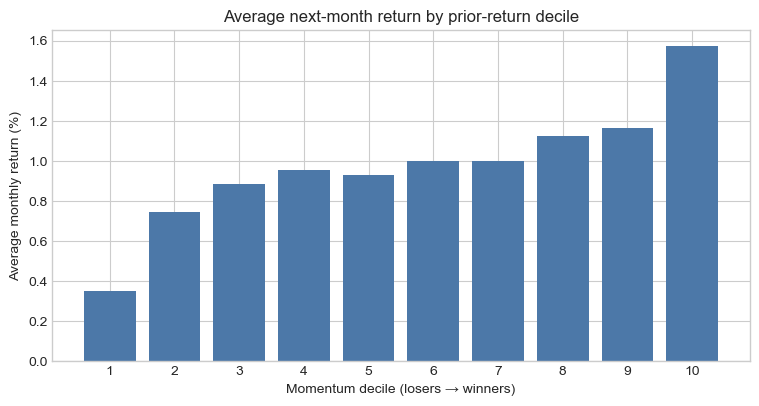

,mean_monthly,mean_annualized,volatility_annualized,sharpe,mean_tstat,maximum_drawdown,nobs
asset,,,,,,,
Winners,0.016,0.189,0.205,0.724,7.769,-0.520,888
Losers,0.003,0.042,0.273,0.007,1.272,-0.934,888
WML,0.012,0.147,0.235,0.626,5.447,-0.808,888


In [5]:
decile_profile = 100 * momentum_portfolios.groupby("momentum_portfolio")["ret"].mean()
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(decile_profile.index.astype(int), decile_profile, color="#4C78A8")
ax.set(title="Average next-month return by prior-return decile", xlabel="Momentum decile (losers → winners)", ylabel="Average monthly return (%)", xticks=range(1, 11))
plt.show()

stock_strategy_returns = wml_frame[["WML_long", "WML_short", "WML"]].rename(
    columns={"WML_long": "Winners", "WML_short": "Losers"}
)
stock_performance = performance_summary(stock_strategy_returns, hac_lags=12)
# Long-only Sharpe ratios use excess returns; WML already is self-financing.
stock_performance.loc[["Winners", "Losers"], "sharpe"] = sharpe_ratio(
    stock_strategy_returns[["Winners", "Losers"]].sub(risk_free, axis=0)
)
stock_performance[["mean_monthly", "mean_annualized", "volatility_annualized", "sharpe", "mean_tstat", "maximum_drawdown", "nobs"]]

The decile profile asks whether subsequent returns rise with past performance rather than relying only on the two extreme portfolios. **WML** simply means winners minus losers: our internal WML is the value-weighted return on momentum decile 10 minus momentum decile 1 in the CRSP–Compustat-linked universe. The spread is self-financing, so the risk-free rate is not subtracted again. The Winners and Losers Sharpe ratios use excess returns; their return and drawdown summaries use the raw long-only returns.

The official Kenneth French momentum return (French, n.d.) is labelled **Mom** in the Data Library and is also commonly called **UMD**, or up minus down. It is constructed from independent 2×3 sorts on size and prior $(2,12)$ return: the average of the small-winner and big-winner portfolios minus the average of the small-loser and big-loser portfolios. Sorting within both size groups and averaging them reduces the extent to which UMD is merely a size position, but it does not statistically residualize or completely strip out size. Our decile WML and official UMD therefore measure the same winner-minus-loser idea using different portfolio architectures.

In [6]:
validation_sample = pd.concat([wml, umd], axis=1).dropna()
validation = pd.Series({
    "Start": validation_sample.index.min(),
    "End": validation_sample.index.max(),
    "N": len(validation_sample),
    "Correlation": validation_sample.corr().iloc[0, 1],
    "WML mean (% monthly)": 100 * validation_sample["WML"].mean(),
    "UMD mean (% monthly)": 100 * validation_sample["UMD"].mean(),
})
validation.to_frame("Internal WML versus official UMD")

,Internal WML versus official UMD
Start,1951-01-01 00:00:00
End,2024-12-01 00:00:00
N,888
Correlation,0.899
WML mean (% monthly),1.224
UMD mean (% monthly),0.658


### 2.3 Factor Spanning Tests: CAPM, FF3, and FF5

We use official UMD as the primary dependent return in CAPM, FF3, and FF5 regressions. The internal WML remains a construction and validation exercise because its CRSP–Compustat-linked universe is narrower than the official stock universe. All models use one common sample. Coefficients are ordinary least-squares estimates, while inference uses Newey–West standard errors with 12 monthly lags to allow for heteroskedasticity and autocorrelation over approximately one year. The lag choice is a transparent convention rather than a universal rule:

$$UMD_t=\alpha+\beta_M MKT_t+\varepsilon_t,$$

$$UMD_t=\alpha+\beta_M MKT_t+\beta_S SMB_t+\beta_H HML_t+\varepsilon_t,$$

$$UMD_t=\alpha+\beta_M MKT_t+\beta_S SMB_t+\beta_H HML_t+\beta_R RMW_t+\beta_C CMA_t+\varepsilon_t.$$

Because UMD is a self-financing winner-minus-loser return, the risk-free rate is not subtracted again. In every model we test $H_0:\alpha=0$ against $H_1:\alpha\neq0$.

A significant alpha means that the tested static model does not absorb UMD's average return over this sample. It does not establish whether the source is behavioral or risk based.

The FF3 regression retains the supplied FF5-derived SMB, making it a nested three-factor benchmark rather than the original B/M-only SMB specification. The model labels refer to Fama and French (1993, 2015); HAC inference follows Newey and West (1987). Alphas concern mean–variance pricing by constant exposures, not exact replication of every monthly return.


In [7]:
models = {
    "CAPM": ["MKT"],
    "FF3": ["MKT", "SMB", "HML"],
    "FF5": ["MKT", "SMB", "HML", "RMW", "CMA"],
}
stock_model_sample = pd.concat([umd, factors], axis=1).dropna()
stock_model_rows = []
for model_name, regressors in models.items():
    fit = time_series_regression(stock_model_sample["UMD"], stock_model_sample[regressors], cov_type="HAC", hac_lags=12)
    row = {
        "Model": model_name,
        "Alpha (% monthly)": 100 * fit.params["const"],
        "NW t(alpha)": fit.tvalues["const"],
        "Adjusted R²": fit.rsquared_adj,
        "N": int(fit.nobs),
    }
    for factor in ["MKT", "SMB", "HML", "RMW", "CMA"]:
        row[f"β {factor}"] = fit.params.get(factor, np.nan)
        row[f"NW t(β {factor})"] = fit.tvalues.get(factor, np.nan)
    stock_model_rows.append(row)
stock_model_table = pd.DataFrame(stock_model_rows).set_index("Model")
stock_model_table

,Alpha (% monthly),NW t(alpha),Adjusted R²,N,β MKT,NW t(β MKT),β SMB,NW t(β SMB),β HML,NW t(β HML),β RMW,NW t(β RMW),β CMA,NW t(β CMA)
Model,,,,,,,,,,,,,,
CAPM,0.710,5.272,0.032,750,-0.170,-2.190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FF3,0.807,6.069,0.078,750,-0.212,-3.124,-0.040,-0.342,-0.314,-2.358,NaN,NaN,NaN,NaN
FF5,0.674,3.567,0.090,750,-0.181,-2.783,-0.004,-0.034,-0.452,-2.844,0.197,0.944,0.330,1.329


Official UMD retains economically and statistically significant alpha in all three models. Its FF5 alpha is 0.674% per month with a Newey–West t-statistic of 3.567, while the adjusted $R^2$ is only 0.090. In FF5, UMD has significantly negative market and value loadings ($t=-2.783$ and $t=-2.844$). Its size loading is essentially zero and insignificant ($t=-0.034$), which is consistent with constructing winner–loser spreads within both small and big firms before averaging them. The positive profitability and investment loadings are not significant at conventional levels ($t=0.944$ and $t=1.329$). These exposures absorb neither most monthly variation nor UMD's average return. Rejecting $H_0:\alpha=0$ says that the static FF5 model does not price momentum over this sample; it does not distinguish behavioral mispricing from omitted or time-varying risk.

## 3. Factor momentum: momentum across factors

Ehsani and Linnainmaa (2022) argue that factor returns themselves exhibit continuation and that this common persistence is related to conventional stock momentum. We test the basic stylized fact in the much smaller five-factor universe available here. This is an application of their question, not an exact replication of their 20-factor analysis.

For each factor, we compare its current return after positive and negative compounded returns over the preceding 12 months. UMD is excluded from the factor set, so any later relationship between factor momentum and UMD is not mechanical.

In [8]:
factor_continuation = conditional_future_returns(factors, lookback=12, skip=1)
difference_t = {}
for factor in factors:
    signal = momentum_signal(factors[factor], lookback=12, skip=1)
    sample = pd.concat([factors[factor].rename("return"), signal.rename("signal")], axis=1).dropna()
    sample["positive"] = sample["signal"].gt(0).astype(float)
    fit = time_series_regression(sample["return"], sample[["positive"]], cov_type="HAC", hac_lags=12)
    difference_t[factor] = fit.tvalues["positive"]
factor_continuation["NW t(difference)"] = pd.Series(difference_t)
factor_continuation[["after_negative", "after_positive", "difference"]] *= 100
factor_continuation

,after_negative,after_positive,difference,n_negative,n_positive,NW t(difference)
asset,,,,,,
MKT,0.383,0.662,0.279,208,530,0.641
SMB,-0.103,0.482,0.585,327,411,2.709
HML,0.001,0.386,0.385,316,422,1.633
RMW,0.077,0.393,0.316,224,514,1.724
CMA,0.047,0.339,0.291,290,448,2.222


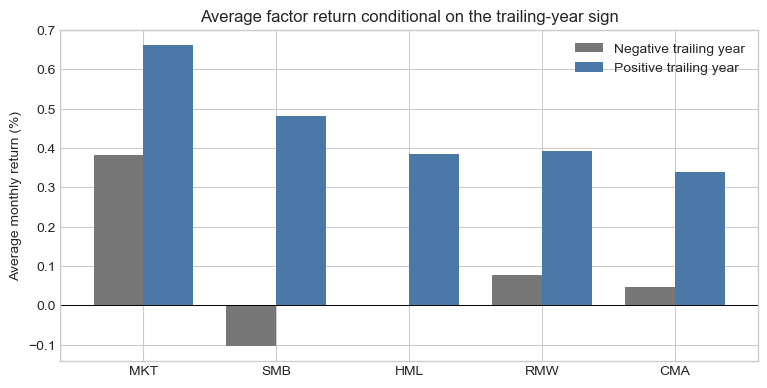

In [9]:
plot_data = factor_continuation[["after_negative", "after_positive"]].rename(columns={"after_negative": "Negative trailing year", "after_positive": "Positive trailing year"})
fig, ax = plt.subplots(figsize=(9, 4.3))
plot_data.plot.bar(ax=ax, color=["#777777", "#4C78A8"], width=0.75)
ax.axhline(0, color="black", linewidth=0.7)
ax.set(title="Average factor return conditional on the trailing-year sign", xlabel="", ylabel="Average monthly return (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(frameon=False)
plt.show()

The comparison asks whether continuation is visible within each factor, not whether every factor must show the same magnitude. The five-factor universe is narrow, and its factors are economically related, so the results should be viewed as a transparent illustration of the factor-continuation hypothesis.

### 3.1 Constructing factor momentum

The time-series factor-momentum strategy takes the sign of each factor's trailing 12-month compounded return and applies it to the next monthly factor return:

$$FMOM_t=\frac{1}{N_t}\sum_{f\in\mathcal A_t}\operatorname{sign}(S_{f,t}^{(12)})F_{f,t}.$$

The available set $\mathcal A_t$ contains factors with both a valid signal and a current return. Weights are normalized by $N_t$; missing factor returns are never filled with zero. UMD is excluded from the factors used to construct FMOM, preventing its later relationship with stock momentum from becoming mechanical.

Explicitly, $S_{f,t}^{(12)}=\prod_{j=1}^{12}(1+F_{f,t-j})-1$ uses calendar months $t-12$ through $t-1$; unlike the stock signal, no intervening month is intentionally skipped. This interpretation requires a consecutive monthly factor index because the factor routine shifts rows rather than checking dates. A zero signal gives a zero position. For nonzero signals, the absolute weights sum to one across available factors; signed weights need not sum to zero. Since the inputs are already excess or self-financing returns, no additional risk-free return is subtracted. Unit gross exposure across factor series is not necessarily unit gross exposure across their underlying securities.

The implementation's exclusion of missing current returns is an ex-post sample-availability convention, not information available when positions are chosen. Positive- and negative-signal group means have separate denominators; their difference is not generally the same portfolio as the sign-weighted FMOM above.


### 3.2 Empirical implementation across factors

We treat MKT, SMB, HML, RMW, and CMA as five diversified traded return series. Each factor is held long following a positive trailing return and short following a negative trailing return; the positions are then averaged across the factors available that month. This is factor momentum in a narrow equity-factor universe, not evidence about a broad multi-asset time-series-momentum strategy.

In [10]:
horizon_strategies = pd.DataFrame({
    f"Formation {lookback}m": factor_momentum(factors, lookback=lookback, skip=1, name=f"Formation {lookback}m")
    for lookback in [1, 3, 6, 12]
}).dropna()
horizon_summary = performance_summary(horizon_strategies, hac_lags=12)
horizon_summary[["mean_annualized", "volatility_annualized", "sharpe", "mean_tstat", "skewness", "maximum_drawdown", "nobs"]]

,mean_annualized,volatility_annualized,sharpe,mean_tstat,skewness,maximum_drawdown,nobs
asset,,,,,,,
Formation 1m,0.039,0.058,0.662,5.688,0.127,-0.160,738
Formation 3m,0.027,0.062,0.438,3.999,0.336,-0.202,738
Formation 6m,0.026,0.058,0.444,3.537,0.222,-0.166,738
Formation 12m,0.032,0.058,0.559,5.305,0.348,-0.176,738


,mean_annualized,volatility_annualized,sharpe,mean_tstat,nobs
asset,,,,,
Equal-weighted factors,0.036,0.044,0.816,5.173,688
Positive-signal factors,0.058,0.065,0.888,7.121,688
Negative-signal factors,0.004,0.096,0.037,0.313,688
Factor momentum,0.032,0.058,0.550,4.915,688


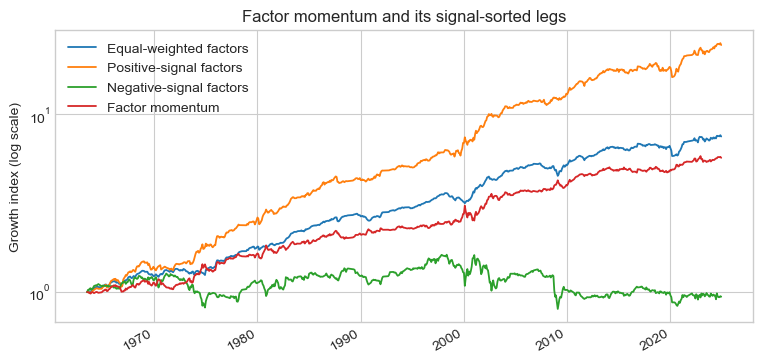

In [11]:
factor_signal = factors.apply(lambda series: momentum_signal(series, lookback=12, skip=1))
winner_factors = factors.where(factor_signal.gt(0)).mean(axis=1).rename("Positive-signal factors")
loser_factors = factors.where(factor_signal.lt(0)).mean(axis=1).rename("Negative-signal factors")
average_factor = factors.mean(axis=1).rename("Equal-weighted factors")
fmom = factor_momentum(factors, lookback=12, skip=1, name="Factor momentum")
factor_strategy_panel = pd.concat([average_factor, winner_factors, loser_factors, fmom], axis=1).dropna()
fmom_performance = performance_summary(factor_strategy_panel, hac_lags=12)
display(fmom_performance[["mean_annualized", "volatility_annualized", "sharpe", "mean_tstat", "nobs"]])

wealth = (1 + factor_strategy_panel).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.3))
wealth.plot(ax=ax, linewidth=1.3)
ax.set_yscale("log")
ax.set(title="Factor momentum and its signal-sorted legs", xlabel="", ylabel="Growth index (log scale)")
ax.legend(frameon=False)
plt.show()

The formation-horizon comparison shows how sensitive factor momentum is to the amount of return history used to determine each position. In the common sample used for the leg comparison, positive-signal factors earn 5.8% annualized, compared with 0.4% for negative-signal factors. The resulting factor-momentum strategy earns 3.2% annualized with a Sharpe ratio of 0.55. The 12-month implementation is retained as the main specification because it matches the factor-continuation question studied by Ehsani and Linnainmaa (2022).

### 3.3 Factor Spanning Tests for Factor Momentum

We evaluate time-series factor momentum against the same nested CAPM, FF3, and FF5 benchmarks used for stock momentum. The common sample is fixed before any model is estimated.

In [12]:
fmom_model_sample = pd.concat([fmom.rename("FMOM"), factors], axis=1).dropna()
fmom_model_rows = []
for model_name, regressors in models.items():
    fit = time_series_regression(fmom_model_sample["FMOM"], fmom_model_sample[regressors], cov_type="HAC", hac_lags=12)
    row = {
        "Model": model_name,
        "Alpha (% monthly)": 100 * fit.params["const"],
        "NW t(alpha)": fit.tvalues["const"],
        "Adjusted R²": fit.rsquared_adj,
        "N": int(fit.nobs),
    }
    for factor in ["MKT", "SMB", "HML", "RMW", "CMA"]:
        row[f"β {factor}"] = fit.params.get(factor, np.nan)
    fmom_model_rows.append(row)
pd.DataFrame(fmom_model_rows).set_index("Model")

,Alpha (% monthly),NW t(alpha),Adjusted R²,N,β MKT,β SMB,β HML,β RMW,β CMA
Model,,,,,,,,,
CAPM,0.271,4.727,-0.001,738,-0.005,NaN,NaN,NaN,NaN
FF3,0.263,4.863,0.015,738,-0.020,0.078,-0.005,NaN,NaN
FF5,0.215,3.460,0.047,738,-0.001,0.078,-0.097,0.023,0.226


These regressions ask whether factor momentum is reducible to constant contemporaneous exposures to the same factors it times. It is not in this sample: the FF5 alpha is 0.215% per month with a Newey–West t-statistic of 3.460. The low adjusted $R^2$ also indicates that static contemporaneous loadings reproduce little of the strategy's time-series variation.

### 3.4 Pricing the stock-momentum deciles

Ehsani and Linnainmaa (2022) ask whether factor momentum explains the cross section of portfolios sorted on past stock returns. Following that logic, we compare three models for our ten internal momentum deciles: FF5, FF5 augmented with official UMD, and FF5 augmented with FMOM. Portfolio returns are converted to excess returns, every model uses the same dates, and individual alpha inference uses Newey–West standard errors with 12 lags. We also report the conventional GRS statistic (Gibbons, Ross, and Shanken, 1989), whose finite-sample reference distribution assumes iid multivariate-normal residuals; it is not made HAC-robust by the separate Newey–West regressions.

In [13]:
momentum_deciles = momentum_portfolios.pivot(index="date", columns="momentum_portfolio", values="ret")
momentum_deciles = momentum_deciles.reindex(columns=range(1, 11))
momentum_deciles.columns = [f"P{portfolio}" for portfolio in range(1, 11)]
pricing_sample = pd.concat([momentum_deciles, risk_free, factors, umd, fmom.rename("FMOM")], axis=1).dropna()
test_assets = pricing_sample[momentum_deciles.columns].sub(pricing_sample["RF"], axis=0)
pricing_models = {
    "FF5": ["MKT", "SMB", "HML", "RMW", "CMA"],
    "FF5 + UMD": ["MKT", "SMB", "HML", "RMW", "CMA", "UMD"],
    "FF5 + FMOM": ["MKT", "SMB", "HML", "RMW", "CMA", "FMOM"],
}
pricing_results = {}
pricing_rows = []
spread = test_assets["P10"] - test_assets["P1"]
for model_name, regressors in pricing_models.items():
    model_factors = pricing_sample[regressors]
    estimates = factor_regressions(test_assets, model_factors, cov_type="HAC", hac_lags=12)
    pricing_results[model_name] = estimates
    errors = pricing_error_summary(estimates)
    spread_fit = time_series_regression(spread, model_factors, cov_type="HAC", hac_lags=12)
    grs = grs_test(test_assets, model_factors)
    pricing_rows.append({
        "Model": model_name,
        "Mean |alpha| (% monthly)": 100 * errors["mean_absolute_alpha"],
        "P10 − P1 alpha (% monthly)": 100 * spread_fit.params["const"],
        "NW t(spread alpha)": spread_fit.tvalues["const"],
        "Average adjusted R²": estimates["adjusted_r_squared"].mean(),
        "GRS statistic": grs["statistic"],
        "GRS p-value": grs["pvalue"],
        "N": grs["nobs"],
    })
pricing_comparison = pd.DataFrame(pricing_rows).set_index("Model")
pricing_comparison

,Mean |alpha| (% monthly),P10 − P1 alpha (% monthly),NW t(spread alpha),Average adjusted R²,GRS statistic,GRS p-value,N
Model,,,,,,,
FF5,0.248,1.336,4.193,0.810,4.399,0.000,738
FF5 + UMD,0.124,0.307,2.989,0.901,3.482,0.000,738
FF5 + FMOM,0.128,0.806,3.048,0.849,3.296,0.000,738


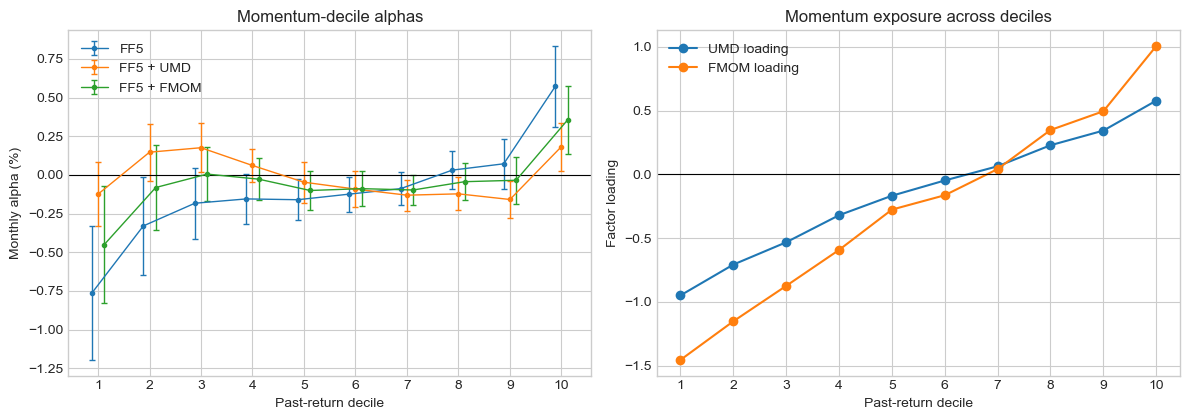

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
x = np.arange(1, 11)
for offset, (model_name, estimates) in zip([-0.12, 0, 0.12], pricing_results.items()):
    axes[0].errorbar(
        x + offset, 100 * estimates["alpha"], yerr=1.96 * 100 * estimates["alpha_se"],
        marker="o", markersize=3, linewidth=1, capsize=2, label=model_name,
    )
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(title="Momentum-decile alphas", xlabel="Past-return decile", ylabel="Monthly alpha (%)", xticks=x)
axes[0].legend(frameon=False)
axes[1].plot(x, pricing_results["FF5 + UMD"]["beta_UMD"], marker="o", label="UMD loading")
axes[1].plot(x, pricing_results["FF5 + FMOM"]["beta_FMOM"], marker="o", label="FMOM loading")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(title="Momentum exposure across deciles", xlabel="Past-return decile", ylabel="Factor loading", xticks=x)
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

Both added factors reduce the pricing errors left by FF5, but official UMD performs better in this application. Mean absolute alpha falls from 0.248% per month under FF5 to 0.124% with UMD and 0.128% with FMOM. The P10-minus-P1 alpha falls from 1.336% to 0.307% with UMD and 0.806% with FMOM; both remaining spreads are statistically significant with Newey–West t-statistics near 3. The GRS test rejects all three models jointly. Under FF5 + FMOM, the P7 alpha is marginally significant at 5% ($p=0.047$). The loading panel shows how exposure changes across the momentum deciles, but the five-factor FMOM constructed here does not reproduce the paper's result that factor momentum fully absorbs stock momentum. That difference is unsurprising given our much narrower factor universe and different stock sample, and it is evidence about this application rather than a failed or successful replication.

### 3.5 Stock and factor momentum spanning

The final tests ask whether official stock momentum and the internally constructed factor-momentum strategy add average return beyond constant exposures to one another and FF5:

$$UMD_t=\alpha+\boldsymbol\beta'FF5_t+\gamma FMOM_t+\varepsilon_t,$$

$$FMOM_t=\alpha+\boldsymbol\beta'FF5_t+\gamma UMD_t+\varepsilon_t.$$

Both regressions use one identical complete sample. Ehsani and Linnainmaa use a much broader factor universe and different source data, so our estimates are an application of their question rather than a replication of their headline result.

In [15]:
spanning_sample = pd.concat([umd, fmom.rename("FMOM"), factors], axis=1).dropna()
spanning_specs = {
    "UMD on FF5 + FMOM": ("UMD", ["MKT", "SMB", "HML", "RMW", "CMA", "FMOM"], "FMOM"),
    "FMOM on FF5 + UMD": ("FMOM", ["MKT", "SMB", "HML", "RMW", "CMA", "UMD"], "UMD"),
}
spanning_rows = []
for label, (dependent, regressors, momentum_regressor) in spanning_specs.items():
    fit = time_series_regression(spanning_sample[dependent], spanning_sample[regressors], cov_type="HAC", hac_lags=12)
    spanning_rows.append({
        "Regression": label,
        "Alpha (% monthly)": 100 * fit.params["const"],
        "NW t(alpha)": fit.tvalues["const"],
        "Momentum loading": fit.params[momentum_regressor],
        "NW t(loading)": fit.tvalues[momentum_regressor],
        "Adjusted R²": fit.rsquared_adj,
        "N": int(fit.nobs),
        "Start": spanning_sample.index.min(),
        "End": spanning_sample.index.max(),
    })
spanning_table = pd.DataFrame(spanning_rows).set_index("Regression")
spanning_table

,Alpha (% monthly),NW t(alpha),Momentum loading,NW t(loading),Adjusted R²,N,Start,End
Regression,,,,,,,,
UMD on FF5 + FMOM,0.338,2.264,1.558,14.732,0.450,738,1963-07-01,2024-12-01
FMOM on FF5 + UMD,0.044,0.854,0.255,9.823,0.425,738,1963-07-01,2024-12-01


The spanning result is directional. UMD retains a 0.338% monthly alpha after controlling for FF5 and FMOM ($t=2.264$), so this five-factor FMOM construction does not fully span conventional stock momentum. FMOM's remaining alpha after controlling for FF5 and UMD is only 0.044% ($t=0.854$), so we cannot reject zero alpha for FMOM conditional on FF5 and UMD in this sample. This is consistent with mean–variance spanning but does not establish it or imply exact return replication. The significant cross-loadings and adjusted $R^2$ near 0.45 nevertheless show substantial overlap.

## References

- Campbell, J. Y., Lo, A. W., and MacKinlay, A. C. (1997). *The econometrics of financial markets*. Princeton University Press. [Stable book record](https://www.jstor.org/stable/j.ctt7skm5).

- Daniel, K., and Moskowitz, T. J. (2016). Momentum crashes. *Journal of Financial Economics*, 122(2), 221–247. [DOI](https://doi.org/10.1016/j.jfineco.2015.12.002).

- Ehsani, S., and Linnainmaa, J. T. (2022). Factor momentum and the momentum factor. *The Journal of Finance*, 77(3), 1877–1919. [DOI](https://doi.org/10.1111/jofi.13131).

- Fama, E. F. (1970). Efficient capital markets: A review of theory and empirical work. *The Journal of Finance*, 25(2), 383–417. [DOI](https://doi.org/10.2307/2325486).

- Fama, E. F., and French, K. R. (1993). Common risk factors in the returns on stocks and bonds. *Journal of Financial Economics*, 33(1), 3–56. [DOI](https://doi.org/10.1016/0304-405X(93)90023-5).

- Fama, E. F., and French, K. R. (2015). A five-factor asset pricing model. *Journal of Financial Economics*, 116(1), 1–22. [DOI](https://doi.org/10.1016/j.jfineco.2014.10.010).

- French, K. R. (n.d.). Detail for monthly momentum factor (Mom). *Data Library, Dartmouth College*. [Construction details](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/det_mom_factor.html). Accessed 10 October 2026.

- Gibbons, M. R., Ross, S. A., and Shanken, J. (1989). A test of the efficiency of a given portfolio. *Econometrica*, 57(5), 1121–1152. [DOI](https://doi.org/10.2307/1913625).

- Hong, H., and Stein, J. C. (1999). A unified theory of underreaction, momentum trading, and overreaction in asset markets. *The Journal of Finance*, 54(6), 2143–2184. [DOI](https://doi.org/10.1111/0022-1082.00184).

- Jegadeesh, N., and Titman, S. (1993). Returns to buying winners and selling losers: Implications for stock market efficiency. *The Journal of Finance*, 48(1), 65–91. [DOI](https://doi.org/10.1111/j.1540-6261.1993.tb04702.x).

- Lo, A. W., and MacKinlay, A. C. (1990). When are contrarian profits due to stock market overreaction? *The Review of Financial Studies*, 3(2), 175–205. [DOI](https://doi.org/10.1093/rfs/3.2.175).

- Newey, W. K., and West, K. D. (1987). A simple, positive semi-definite, heteroskedasticity and autocorrelation consistent covariance matrix. *Econometrica*, 55(3), 703–708. [DOI](https://doi.org/10.2307/1913610).
